In [4]:
import os
import zarr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

path7 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"

G = zarr.open_array(os.path.join(path7, "MTs.zarr"), mode='r')
R = zarr.open_array(os.path.join(path7, "MTs_red.zarr"), mode='r')
B = zarr.open_array(os.path.join(path7, "beads.zarr"), mode='r')

# --- カラーマップ作成 ---
colormap_data = {
    "MTs": [(0, 0, 0), (119/255, 217/255, 168/255)],
    "MTs_red": [(0, 0, 0, 0.0), (255/255, 75/255, 0)],
    "beads": [(0, 0, 0), (136/255, 204/255, 238/255)]
}
colormaps = {}
for name, colors in colormap_data.items():
    colormaps[name] = LinearSegmentedColormap.from_list(name, colors)


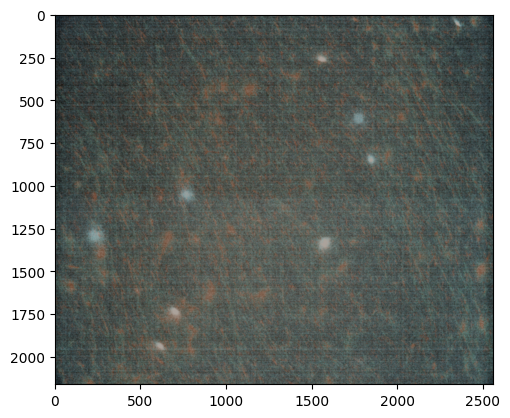

In [6]:
plt.imshow(G[0, :, :], cmap = colormaps['MTs'])
plt.imshow(R[0, :, :], cmap = colormaps['MTs_red'], alpha = 0.8)
plt.imshow(B[0, :, :], cmap = colormaps['beads'], alpha = 0.6)

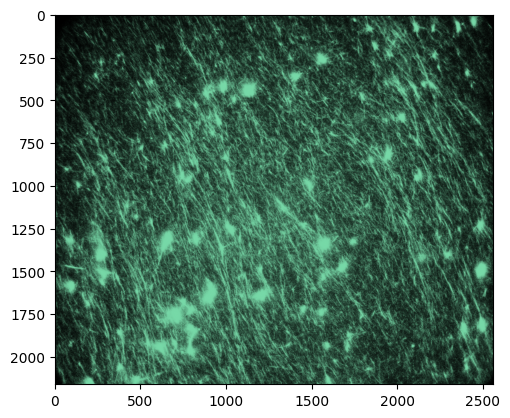

In [ ]:
import cv2
import numpy as np

def gamma_correction(img, gamma):
    # テーブルを作成する。
    table = (np.arange(256) / 255) ** gamma * 255
    # [0, 255] でクリップし、uint8 型にする。
    table = np.clip(table, 0, 255).astype(np.uint8)

    return cv2.LUT(img, table)



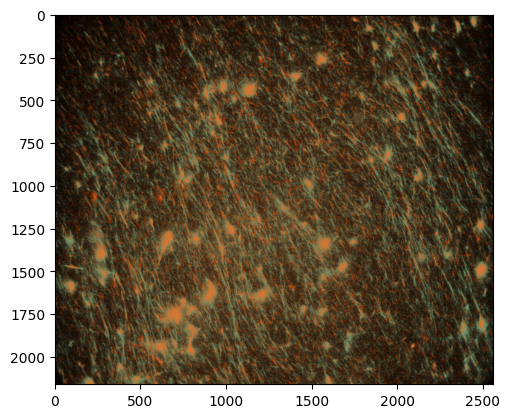

In [16]:
GT=gamma_correction(G[0,:,:], 1.9)
RT=gamma_correction(R[0,:,:], 1.4)
plt.imshow(GT, cmap = colormaps['MTs'])
plt.imshow(RT, cmap = colormaps['MTs_red'], alpha = 0.7)

In [37]:
def apply_color(gray_image, color_rgb):
    """
    グレイスケール画像を指定したRGB色に着色します。
    引数:
        gray_image: 2次元NumPy配列 (uint8)
        color_rgb: (R, G, B) のタプル。各値は0-255。
    戻り値:
        3次元NumPy配列 (高さ, 幅, 3) (float型)
    """
    # 0.0〜1.0 に正規化
    normalized_img = gray_image.astype(float) / 255.0
    
    # カラー画像の配列を準備 (H, W, 3)
    # ブロードキャスト機能を使って、(H, W, 1) * (3,) の計算を行います
    # これにより、明るい部分は指定色が濃く、暗い部分は黒くなります
    colored_img = normalized_img[:, :, np.newaxis] * np.array(color_rgb)
    
    return colored_img

MTs = (0, 255, 0)
MTs_red = (255, 0, 0)
beads = (0, 0, 255)

layer1 = apply_color(G[0,:,:], MTs)
layer2 = apply_color(R[0,:,:], MTs_red)
layer3 = apply_color(B[0,:,:], beads)

(np.float64(-0.5), np.float64(2559.5), np.float64(2159.5), np.float64(-0.5))

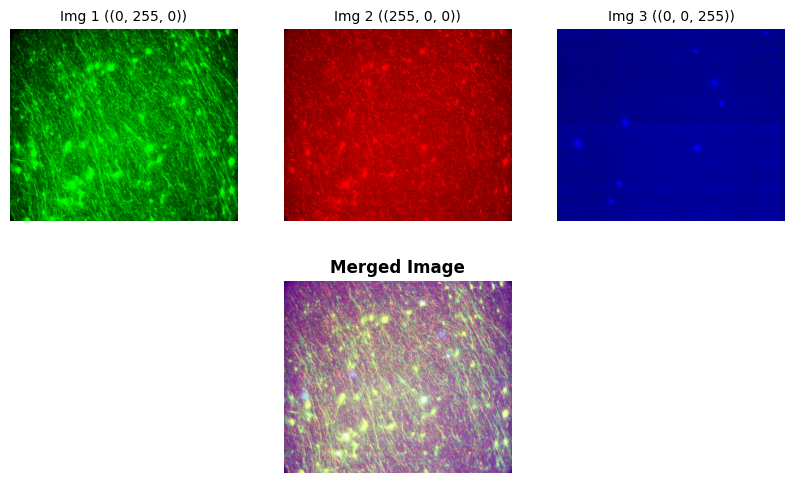

In [38]:
combined_float = layer1 + layer2 + layer3

combined_clipped = np.clip(combined_float, 0, 255).astype(np.uint8)

# --- 結果の表示 ---
plt.figure(figsize=(10, 6))

# 元画像の表示
titles = [f"Img 1 ({MTs})", f"Img 2 ({MTs_red})", f"Img 3 ({beads})"]
layers = [layer1, layer2, layer3]

for i in range(3):
    plt.subplot(2, 3, i+1)
    # 表示用にuint8に変換して表示
    show_img = np.clip(layers[i], 0, 255).astype(np.uint8)
    plt.imshow(show_img)
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

# 合成画像の表示
plt.subplot(2, 3, 5)
plt.imshow(combined_clipped)
plt.title("Merged Image", fontsize=12, fontweight='bold')
plt.axis('off')